In [ ]:
spark.stop()

In [1]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

### armar lista credicash

In [31]:
cl_base1 = fecha_a_nombre('2026-05-01')

query = f"""
    select   
        numero_documento as dni_cliente,
        cl_id,
        '17' as id_servicio,
        CONCAT(isnull(nombre,''),',') AS nombre_add,
        cast(oferta as int) as oferta_max,
        cast(oferta_electro as decimal(18,2)) as oferta_electro,
        cast(tasa_electro as float) as tasa_electro,
        cast(plazo_electro as int) as plazo_electro,
        cast(cme_electro as float) as cme_electro,
        cast(oferta_credicash as decimal(18,2)) as oferta_credicash,
        cast(tasa_credicash as float) as tasa_credicash,
        cast(plazo_credicash as int) as plazo_credicash,
        cast(cme_credicash as float) as cme_credicash,
        perfil,
      [cl_telf1]
      ,[cl_telf2]
      ,[cl_telf3]
      ,[cl_telf4]
      ,[cl_telf5]
      ,[cl_telf6]
      ,[cl_telf7]
      ,[cl_telf8]
      ,[cl_telf9]
      ,[cl_telf10]
      ,[cl_movil]
      ,[cl_celular]
      ,[cl_telefono],

        plazo,
        tasa,
        cme_disponible,
        lote,
        proveedor,
        msi,
        flg_credicash,
        propension,
        campana,
        cl_carga,
        obs_fcc,
        semaforo,
        region,
        tienda_ir,
        situacion_laboral,
        score_telefono,
        marca_pd,
        grupo_segmento,
        producto_externo,
        propension_electro,
        propension_credicash,
        flg_cruce_recurrente,
        flg_cruce as alta_demanda,
        demanda,
        prioridad,
        inicio,
        case
            when cl_estado>1  then 'retiro'
            when cl_estado is null  then 'revisar'
            else 'no_aplica'
        end as retiro ,           
        fin,
        producto_interno,
        case   
            when cast(flg_aahh as int) = 0 then 'no_emergente'
            when cast(flg_aahh as int) = 1 then 'emergente'
        end as flg_aahh,
        intensidad_max,
        frescura
    from valentina.dbo.alfcc_clientes 
    where cl_base='{cl_base1}'
    and cl_estado=1
    """
df_base=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

df_base= df_base.withColumn(
    "seg_oferta",
        F.when((F.col("Oferta_max") >= 1000) & (F.col("Oferta_max") <= 2000), "A. 1000 A 2000")
        .when((F.col("Oferta_max") > 2000) & (F.col("Oferta_max") <= 3000), "B. 2000 A 3000")
        .when((F.col("Oferta_max") > 3000) & (F.col("Oferta_max") <= 4000), "C. 3000 A 4000")
        .when((F.col("Oferta_max") > 4000) & (F.col("Oferta_max") <= 5000), "D. 4000 A 5000")
        .when((F.col("Oferta_max") > 5000) & (F.col("Oferta_max") <= 7000), "E. 5000 A 7000")
        .when((F.col("Oferta_max") > 7000) & (F.col("Oferta_max") <= 10000), "F. 7000 A 10000")
        .when((F.col("Oferta_max") > 10000) & (F.col("Oferta_max") <= 15000), "G. 10000 A 15000")
        .when((F.col("Oferta_max") > 15000) & (F.col("Oferta_max") <= 20000), "H. 15000 A 20000")
        .when((F.col("Oferta_max") > 20000) & (F.col("Oferta_max") <= 30000), "I. 20000 A 30000")
        .when(F.col("Oferta_max") > 30000, "J. 30000 A MÁS")
    )
df_base= df_base.withColumn(
    "seg_oferta_credicash",
        F.when((F.col("oferta_credicash") >= 1000) & (F.col("oferta_credicash") <= 2000), "A. 1000 A 2000")
        .when((F.col("oferta_credicash") > 2000) & (F.col("oferta_credicash") <= 3000), "B. 2000 A 3000")
        .when((F.col("oferta_credicash") > 3000) & (F.col("oferta_credicash") <= 4000), "C. 3000 A 4000")
        .when((F.col("oferta_credicash") > 4000) & (F.col("oferta_credicash") <= 5000), "D. 4000 A 5000")
        .when((F.col("oferta_credicash") > 5000) & (F.col("oferta_credicash") <= 7000), "E. 5000 A 7000")
        .when((F.col("oferta_credicash") > 7000) & (F.col("oferta_credicash") <= 10000), "F. 7000 A 10000")
        .when((F.col("oferta_credicash") > 10000) & (F.col("oferta_credicash") <= 15000), "G. 10000 A 15000")
        .when((F.col("oferta_credicash") > 15000) & (F.col("oferta_credicash") <= 20000), "H. 15000 A 20000")
        .when((F.col("oferta_credicash") > 20000) & (F.col("oferta_credicash") <= 30000), "I. 20000 A 30000")
        .when(F.col("oferta_credicash") > 30000, "J. 30000 A MÁS")
    )

df_base= df_base.withColumn(
    "seg_oferta_electro",
        F.when((F.col("oferta_electro") >= 1000) & (F.col("oferta_electro") <= 2000), "A. 1000 A 2000")
        .when((F.col("oferta_electro") > 2000) & (F.col("oferta_electro") <= 3000), "B. 2000 A 3000")
        .when((F.col("oferta_electro") > 3000) & (F.col("oferta_electro") <= 4000), "C. 3000 A 4000")
        .when((F.col("oferta_electro") > 4000) & (F.col("oferta_electro") <= 5000), "D. 4000 A 5000")
        .when((F.col("oferta_electro") > 5000) & (F.col("oferta_electro") <= 7000), "E. 5000 A 7000")
        .when((F.col("oferta_electro") > 7000) & (F.col("oferta_electro") <= 10000), "F. 7000 A 10000")
        .when((F.col("oferta_electro") > 10000) & (F.col("oferta_electro") <= 15000), "G. 10000 A 15000")
        .when((F.col("oferta_electro") > 15000) & (F.col("oferta_electro") <= 20000), "H. 15000 A 20000")
        .when((F.col("oferta_electro") > 20000) & (F.col("oferta_electro") <= 30000), "I. 20000 A 30000")
        .when(F.col("oferta_electro") > 30000, "J. 30000 A MÁS")
    )

df_base = df_base.withColumn(
    "seg_tasa_credicash",
    F.when(F.col("tasa_credicash") < 20, "a. [0,20%)")
    .when((F.col("tasa_credicash") >= 20) & (F.col("tasa_credicash") < 30), "b. [20%,30%)")
    .when((F.col("tasa_credicash") >= 30) & (F.col("tasa_credicash") < 40), "c. [30%,40%)")
    .when((F.col("tasa_credicash") >= 40) & (F.col("tasa_credicash") < 50), "d. [40%,50%)")
    .when((F.col("tasa_credicash") >= 50) & (F.col("tasa_credicash") < 60), "e. [50%,60%)")
    .when((F.col("tasa_credicash") >= 60) & (F.col("tasa_credicash") < 70), "f. [60%,70%)")
    .when((F.col("tasa_credicash") >= 70) & (F.col("tasa_credicash") < 80), "g. [70%,80%)")
    .when(F.col("tasa_credicash") >= 80, "h. [80%,+)")
    .otherwise("z. otros")
)

df_base = df_base.withColumn(
    "seg_tasa_electro",
    F.when(F.col("tasa_electro") < 20, "a. [0,20%)")
    .when((F.col("tasa_electro") >= 20) & (F.col("tasa_electro") < 30), "b. [20%,30%)")
    .when((F.col("tasa_electro") >= 30) & (F.col("tasa_electro") < 40), "c. [30%,40%)")
    .when((F.col("tasa_electro") >= 40) & (F.col("tasa_electro") < 50), "d. [40%,50%)")
    .when((F.col("tasa_electro") >= 50) & (F.col("tasa_electro") < 60), "e. [50%,60%)")
    .when((F.col("tasa_electro") >= 60) & (F.col("tasa_electro") < 70), "f. [60%,70%)")
    .when((F.col("tasa_electro") >= 70) & (F.col("tasa_electro") < 80), "g. [70%,80%)")
    .when(F.col("tasa_electro") >= 80, "h. [80%,+)")
    .otherwise("z. otros")
)


df_base= df_base.withColumn(
    "seg_cme_electro",
        F.when((F.col("cme_electro") >= 1000) & (F.col("cme_electro") <= 2000), "A. 1000 A 2000")
        .when((F.col("cme_electro") > 2000) & (F.col("cme_electro") <= 3000), "B. 2000 A 3000")
        .when((F.col("cme_electro") > 3000) & (F.col("cme_electro") <= 4000), "C. 3000 A 4000")
        .when((F.col("cme_electro") > 4000) & (F.col("cme_electro") <= 5000), "D. 4000 A 5000")
        .when((F.col("cme_electro") > 5000) & (F.col("cme_electro") <= 7000), "E. 5000 A 7000")
        .when((F.col("cme_electro") > 7000) & (F.col("cme_electro") <= 10000), "F. 7000 A 10000")
        .when((F.col("cme_electro") > 10000) & (F.col("cme_electro") <= 15000), "G. 10000 A 15000")
        .when((F.col("cme_electro") > 15000) & (F.col("cme_electro") <= 20000), "H. 15000 A 20000")
        .when((F.col("cme_electro") > 20000) & (F.col("cme_electro") <= 30000), "I. 20000 A 30000")
        .when(F.col("cme_electro") > 30000, "J. 30000 A MÁS")
    )
df_base= df_base.withColumn(
    "seg_cme_credicash",
        F.when((F.col("cme_credicash") >= 1000) & (F.col("cme_credicash") <= 2000), "A. 1000 A 2000")
        .when((F.col("cme_credicash") > 2000) & (F.col("cme_credicash") <= 3000), "B. 2000 A 3000")
        .when((F.col("cme_credicash") > 3000) & (F.col("cme_credicash") <= 4000), "C. 3000 A 4000")
        .when((F.col("cme_credicash") > 4000) & (F.col("cme_credicash") <= 5000), "D. 4000 A 5000")
        .when((F.col("cme_credicash") > 5000) & (F.col("cme_credicash") <= 7000), "E. 5000 A 7000")
        .when((F.col("cme_credicash") > 7000) & (F.col("cme_credicash") <= 10000), "F. 7000 A 10000")
        .when((F.col("cme_credicash") > 10000) & (F.col("cme_credicash") <= 15000), "G. 10000 A 15000")
        .when((F.col("cme_credicash") > 15000) & (F.col("cme_credicash") <= 20000), "H. 15000 A 20000")
        .when((F.col("cme_credicash") > 20000) & (F.col("cme_credicash") <= 30000), "I. 20000 A 30000")
        .when(F.col("cme_credicash") > 30000, "J. 30000 A MÁS")
    )    


In [32]:

query = """
  SELECT dni_cliente FROM cronox.dbo.borrar_credicash_01
    """
df_list = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

In [33]:
df_base=df_base.join(df_list.select('dni_cliente'),['dni_cliente'],'leftanti')

In [34]:
df_base=df_base.select('dni_cliente', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4', 'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9', 'cl_telf10', 'cl_movil', 'cl_celular', 'cl_telefono')

In [35]:
from functools import reduce

columnas_telefonos = [
    'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4',
    'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8',
    'cl_telf9', 'cl_telf10',
    'cl_movil', 'cl_celular', 'cl_telefono'
]

condiciones = [
    F.col(c).cast('string').rlike(r'^9\d{8}$')
    for c in columnas_telefonos
]

condicion_final = reduce(lambda a, b: a | b, condiciones)
condicion_final_negada = ~condicion_final


In [36]:
df_base.filter(condicion_final_negada).count()
# df_base=df_base.filter(condicion_final_negada)
# df_base = df_base.filter(condicion_final)


14457

In [37]:
df_base=df_base.select('dni_cliente')

In [9]:
overwrite_table_SQL(spark,df_base,f'tb_dni_credicash_borrar',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [ ]:
# def pool_tnumeros_valentina(spark,dni_valentina,tb_Numero,tb_name_tnum):
def pool_tnumeros_valentina_prueba(spark,dni_valentina,tb_Numero):

    cross_columns_a1=cross_columns_int
    dni_a1=dni_int
    fecha_ref_a1=fecha_ref_int
    peso_ref_a1=peso_int
    tb_a1=tb_int

    cross_columns_a2=cross_columns_web
    dni_a2=dni_web
    fecha_ref_a2=fecha_ref_web
    peso_ref_a2=peso_web
    tb_a2=tb_web

    cross_columns_a3=cross_columns_hu
    dni_a3=dni_hu
    fecha_ref_a3=fecha_ref_hu
    peso_ref_a3=peso_hu
    tb_a3=tb_hu

    cross_columns_a4=cross_columns_epc
    dni_a4=dni_epc
    fecha_ref_a4=fecha_ref_epc
    peso_ref_a4=peso_epc
    tb_a4=tb_epc

    cross_columns_a5=cross_columns_etk
    dni_a5=dni_etk
    fecha_ref_a5=fecha_ref_etk
    peso_ref_a5=peso_etk
    tb_a5=tb_etk

    query = f"""
        SELECT DISTINCT dni_cliente,contacto,tipo_telf,dias_antiguedad,peso
        FROM (
            SELECT 
                right('00000000'+a.{dni_a1},8) AS dni_cliente,
                t.contacto,
                t.tipo_telf,
                DATEDIFF(DAY, a.{fecha_ref_a1}, GETDATE()) AS dias_antiguedad,
                {peso_ref_a1} as peso
            FROM DANTALION.dbo.{tb_a1} a
            CROSS APPLY (
                VALUES {cross_columns_a1}
            ) t(tipo_telf, contacto)
            WHERE EXISTS (
                SELECT 1
                FROM DANTALION.dbo.{tb_Numero} b
                WHERE right('00000000'+b.{dni_valentina},8) = right('00000000'+a.{dni_a1},8)
            )
            AND t.contacto IS NOT NULL
            AND t.contacto <> ''
            AND LEN(t.contacto) = 9
            AND t.contacto LIKE '9%'
            AND a.{dni_a1} IS NOT NULL

            UNION

            SELECT 
                a.{dni_a2} AS dni_cliente,
                t.contacto,
                t.tipo_telf,
                DATEDIFF(DAY, a.{fecha_ref_a2}, GETDATE()) AS dias_antiguedad,
                {peso_ref_a2} as peso
            FROM DANTALION.dbo.{tb_a2} a
            CROSS APPLY (
                VALUES {cross_columns_a2}
            ) t(tipo_telf, contacto)
            WHERE EXISTS (
                SELECT 1
                FROM DANTALION.dbo.{tb_Numero} b
                WHERE right('00000000'+b.{dni_valentina},8) = right('00000000'+a.{dni_a2},8)
            )
            AND t.contacto IS NOT NULL
            AND t.contacto <> ''
            AND LEN(t.contacto) = 9
            AND t.contacto LIKE '9%'
            AND a.{dni_a2} IS NOT NULL

            UNION

            SELECT 
                a.{dni_a3} AS dni_cliente,
                t.contacto,
                t.tipo_telf,
                DATEDIFF(DAY, a.{fecha_ref_a3}, GETDATE()) AS dias_antiguedad,
                {peso_ref_a3} as peso
            FROM DANTALION.dbo.{tb_a3} a
            CROSS APPLY (
                VALUES {cross_columns_a3}
            ) t(tipo_telf, contacto)
            WHERE EXISTS (
                SELECT 1
                FROM DANTALION.dbo.{tb_Numero} b
                WHERE right('00000000'+b.{dni_valentina},8) = right('00000000'+a.{dni_a3},8)
            )
            AND t.contacto IS NOT NULL
            AND t.contacto <> ''
            AND LEN(t.contacto) = 9
            AND t.contacto LIKE '9%'
            AND a.{dni_a3} IS NOT NULL

            UNION

            SELECT 
                a.{dni_a4} AS dni_cliente,
                t.contacto,
                t.tipo_telf,
                DATEDIFF(DAY, a.{fecha_ref_a4}, GETDATE()) AS dias_antiguedad,
                {peso_ref_a4} as peso
            FROM DANTALION.dbo.{tb_a4} a
            CROSS APPLY (
                VALUES {cross_columns_a4}
            ) t(tipo_telf, contacto)
            WHERE EXISTS (
                SELECT 1
                FROM DANTALION.dbo.{tb_Numero} b
                WHERE right('00000000'+b.{dni_valentina},8) = right('00000000'+a.{dni_a4},8)
            )
            AND t.contacto IS NOT NULL
            AND t.contacto <> ''
            AND LEN(t.contacto) = 9
            AND t.contacto LIKE '9%'
            AND a.{dni_a4} IS NOT NULL

            UNION

            SELECT 
                a.{dni_a5} AS dni_cliente,
                t.contacto,
                t.tipo_telf,
                DATEDIFF(DAY, a.{fecha_ref_a5}, GETDATE()) AS dias_antiguedad,
                {peso_ref_a5} as peso
            FROM DANTALION.dbo.{tb_a5} a
            CROSS APPLY (
                VALUES {cross_columns_a5}
            ) t(tipo_telf, contacto)
            WHERE EXISTS (
                SELECT 1
                FROM DANTALION.dbo.{tb_Numero} b
                WHERE right('00000000'+b.{dni_valentina},8) = right('00000000'+a.{dni_a5},8)
            )
            AND t.contacto IS NOT NULL
            AND t.contacto <> ''
            AND LEN(t.contacto) = 9
            AND t.contacto LIKE '9%'
            AND a.{dni_a5} IS NOT NULL

        ) t
    """

    df_ref01=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

    window_spec = Window.partitionBy("dni_cliente","contacto").orderBy(F.col("peso").asc_nulls_last(),F.col("dias_antiguedad").asc_nulls_last())
    df_ref01 = df_ref01.withColumn("ref1_vici", row_number().over(window_spec))
    df_ref01 = df_ref01.filter(F.col('ref1_vici')==1).drop('ref1_vici')    

    return  df_ref01.withColumn(
        "dni_cliente",
        F.right(
            F.concat(F.lit("00000000"), F.col("dni_cliente")),
            F.lit(8)
        )
    )
    # overwrite_table_SQL(spark,df_ref01,f'{tb_name_tnum}',server_kishin,user_kishin,pwd_kishin,db_kishin)



In [14]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

def pool_tnumeros_valentina_dantalion(spark, dni_valentina, tb_Numero):

    fuentes = [
        (cross_columns_dinners_tc, dni_dinners_tc, fecha_ref_dinners_tc, peso_dinners_tc, tb_dinners_tc),
        (cross_columns_dinners_pp, dni_dinners_pp, fecha_ref_dinners_pp, peso_dinners_pp, tb_dinners_pp),
        (cross_columns_cenco_pp, dni_cenco_pp, fecha_ref_cenco_pp, peso_cenco_pp, tb_cenco_pp),
        (cross_columns_cenco_tc, dni_cenco_tc, fecha_ref_cenco_tc, peso_cenco_tc, tb_cenco_tc),
        (cross_columns_efec_consumo, dni_efec_consumo, fecha_ref_efec_consumo, peso_efec_consumo, tb_efec_consumo),
        (cross_columns_efec_negocio, dni_efec_negocio, fecha_ref_efec_negocio, peso_efec_negocio, tb_efec_negocio),
    ]

    selects = []

    for cross_columns, dni_col, fecha_ref, peso, tabla in fuentes:

        select_sql = f"""
            SELECT 
                RIGHT('00000000' + CAST(a.{dni_col} AS VARCHAR), 8) AS dni_cliente,
                CAST(t.contacto AS VARCHAR) AS contacto,
                t.tipo_telf,
                ISNULL(
                    DATEDIFF(
                        DAY,
                        COALESCE(
                            TRY_CONVERT(DATE, a.{fecha_ref}, 103),
                            TRY_CONVERT(DATE, a.{fecha_ref}, 120),
                            TRY_CONVERT(DATE, a.{fecha_ref})
                        ),
                        GETDATE()
                    ),
                    9999
                ) AS dias_antiguedad,
                {peso} AS peso
            FROM DANTALION.dbo.{tabla} a
            CROSS APPLY (
                VALUES {cross_columns}
            ) t(tipo_telf, contacto)
            WHERE EXISTS (
                SELECT 1
                FROM DANTALION.dbo.{tb_Numero} b
                WHERE RIGHT('00000000' + CAST(b.{dni_valentina} AS VARCHAR), 8)
                    = RIGHT('00000000' + CAST(a.{dni_col} AS VARCHAR), 8)
            )
            AND t.contacto IS NOT NULL
            AND CAST(t.contacto AS VARCHAR) <> ''
            AND LEN(CAST(t.contacto AS VARCHAR)) = 9
            AND CAST(t.contacto AS VARCHAR) LIKE '9%'
            AND a.{dni_col} IS NOT NULL
        """

        selects.append(select_sql)

    query = f"""
        SELECT DISTINCT 
            dni_cliente,
            contacto,
            tipo_telf,
            dias_antiguedad,
            peso
        FROM (
            {' UNION ALL '.join(selects)}
        ) t
    """

    df_ref01 = obtener_tabla_sql(
        spark,
        query,
        server_kishin,
        user_kishin,
        pwd_kishin,
        db_kishin
    )

    window_spec = Window.partitionBy(
        "dni_cliente", "contacto"
    ).orderBy(
        F.col("peso").asc_nulls_last(),
        F.col("dias_antiguedad").asc_nulls_last()
    )

    df_ref01 = (
        df_ref01
        .withColumn("ref1_vici", row_number().over(window_spec))
        .filter(F.col("ref1_vici") == 1)
        .drop("ref1_vici")
        .withColumn(
            "dni_cliente",
            F.right(
                F.concat(F.lit("00000000"), F.col("dni_cliente").cast("string")),
                F.lit(8)
            )
        )
    )

    return df_ref01

In [43]:
df_dni_enriquecido=pool_tnumeros_valentina_prueba(spark,'dni_cliente','tb_dni_credicash_borrar')

In [15]:
df_dni_enriquecido=pool_tnumeros_valentina_dantalion(spark,'dni_cliente','tb_dni_credicash_borrar')


In [16]:
df_dni_enriquecido.show(2)

+-----------+---------+---------+---------------+----+
|dni_cliente| contacto|tipo_telf|dias_antiguedad|peso|
+-----------+---------+---------+---------------+----+
|   00015017|923030110|    cel04|             14|   6|
|   00015017|938742294|    cel03|             14|   6|
+-----------+---------+---------+---------------+----+
only showing top 2 rows


In [17]:

filename='blacklist_celulares.txt'
df_retiro=cargar_archivo_csv(spark,filename,'|',True)


In [18]:
df_retiro=df_retiro.withColumnRenamed('CELULAR','contacto')

In [ ]:
# df_dni_enriquecido.dropDuplicates(['dni_cliente']).count()

In [19]:
# df_dni_enriquecido.join(df_retiro,['contacto'],'leftanti').count()
df_dni_enriquecido=df_dni_enriquecido.join(df_retiro,['contacto'],'leftanti')

In [52]:
df_dni_enriquecido.show(2)

+---------+-----------+---------+---------------+----+
| contacto|dni_cliente|tipo_telf|dias_antiguedad|peso|
+---------+-----------+---------+---------------+----+
|961070974|   00001598|     ip01|             71|  30|
|981824876|   00002318|     ip01|             71|  30|
+---------+-----------+---------+---------------+----+
only showing top 2 rows


In [20]:
df_dni_enriquecido=df_dni_enriquecido.select('dni_cliente','contacto')

In [21]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# 1. Quedarte con DNI + contacto y eliminar duplicados
df_tel = (
    df_dni_enriquecido
    .select("dni_cliente", "contacto")
    .filter(F.col("contacto").isNotNull())
    .dropDuplicates(["dni_cliente", "contacto"])
)

# 2. Numerar contactos por DNI
w = Window.partitionBy("dni_cliente").orderBy("contacto")

df_tel_num = df_tel.withColumn(
    "n_contacto",
    F.row_number().over(w)
)

# 3. Pivotear
df_pivot = (
    df_tel_num
    .groupBy("dni_cliente")
    .pivot("n_contacto")
    .agg(F.first("contacto"))
)

# 4. Renombrar columnas
for c in df_pivot.columns:
    if c != "dni_cliente":
        df_pivot = df_pivot.withColumnRenamed(c, f"contacto_{c}")

# df_pivot.show(3,truncate=False)

In [22]:
df_pivot=df_pivot.select('dni_cliente','contacto_1','contacto_2','contacto_3')

In [23]:
cols_contacto = [c for c in df_pivot.columns if c.startswith('contacto_')]

df_pivot = df_pivot.fillna("0", subset=cols_contacto)

In [38]:
df_valentina=df_pivot.toPandas()

In [25]:
from sqlalchemy import create_engine

engine_mysql = create_engine(
    f"mysql+pymysql://{user_valentina}:{pwd_valentina}@{server_valentina}:{port_mysql}/{db_valentina}"
)


In [ ]:
reemplazo = {
    'dni_cliente': 'col_01',
    'contacto_1': 'col_02',
    'contacto_2': 'col_03',
    'contacto_3': 'col_04',
}
df_valentina = df_valentina.rename(columns=reemplazo)

In [40]:

df_valentina.to_sql(
    name="tb_temporal",
    con=engine_mysql,
    if_exists="append",
    index=False,
    chunksize=1000
)

14457

In [42]:
from sqlalchemy import text

query = """
UPDATE crm_target.alfcc_clientes a
INNER JOIN crm_target.tb_temporal b
    ON a.NUMERO_DOCUMENTO = b.col_01 
SET 
    a.cl_telf9 = b.col_02,
    a.cl_telf8 = b.col_03,
    a.cl_telf10 = b.col_04
WHERE 
    a.cl_base = 'mayo 2026'
"""

with engine_mysql.begin() as conn:
    result = conn.execute(text(query))
    print("Filas afectadas:", result.rowcount)

Filas afectadas: 14457


In [43]:
from sqlalchemy import text

query = """
DELETE FROM crm_target.tb_temporal
"""

with engine_mysql.begin() as conn:
    result = conn.execute(text(query))
    print("Filas eliminadas:", result.rowcount)

Filas eliminadas: 14457


In [41]:
from sqlalchemy import text

query = """
UPDATE crm_target.tb_temporal a
INNER JOIN crm_target.alfin_clientes b
    ON b.NUMERO_DOCUMENTO = a.col_01 
SET 
    a.col_02 = b.cl_telf1,
    a.col_03 = b.cl_telf2,
    a.col_04 = b.cl_telf3
"""

with engine_mysql.begin() as conn:
    result = conn.execute(text(query))
    print("Filas afectadas:", result.rowcount)

Filas afectadas: 460


In [46]:
df_retiro.show(2)

+---------+
|  CELULAR|
+---------+
|900000202|
|900000531|
+---------+
only showing top 2 rows


In [44]:
print(df_dni_enriquecido.columns)

['dni_cliente', 'contacto', 'tipo_telf', 'dias_antiguedad', 'peso']


In [40]:
df_dni_enriquecido.filter(F.col('contacto').isNull()).count()

0

In [ ]:
window_spec = Window.partitionBy("dni_cliente","contacto").orderBy(F.col("dni_cliente").asc_nulls_last(),F.col("dias_antiguedad").asc_nulls_last())
df_dni_enriquecido = df_dni_enriquecido.withColumn("ref1_vici", row_number().over(window_spec))
df_dni_enriquecido = df_dni_enriquecido.filter(F.col('ref1_vici')==1).drop('ref1_vici','peso')    


In [41]:
df_dni_enriquecido.show(5)

+-----------+---------+---------+---------------+
|dni_cliente| contacto|tipo_telf|dias_antiguedad|
+-----------+---------+---------+---------------+
|   00001598|961070974|     ip01|             70|
|   00002318|981824876|     ip01|             70|
|   00011391|959915696|     ip02|            439|
|   00011391|971244027|     ip01|            439|
|   00015497|964063785|     ip01|            439|
+-----------+---------+---------+---------------+
only showing top 5 rows


In [ ]:
df_list_filtrada = df_base.select(
    'dni_cliente'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'dni_credicash_para_enriquecer.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [3]:
df_list.groupBy('fecha_llamada') \
    .count() \
    .orderBy('fecha_llamada') \
    .show(30, truncate=False)

+-------------+-----+
|fecha_llamada|count|
+-------------+-----+
|NULL         |29046|
|2026-05-02   |2736 |
|2026-05-04   |6383 |
|2026-05-05   |10232|
|2026-05-06   |13660|
|2026-05-07   |9122 |
|2026-05-08   |10994|
|2026-05-09   |9456 |
|2026-05-11   |6046 |
|2026-05-12   |10441|
|2026-05-13   |11046|
|2026-05-14   |9215 |
+-------------+-----+



In [7]:
filename='20260513_TARGET_PRIORIDAD.txt'
df_base=cargar_archivo_csv(spark,filename,'|',True)

In [ ]:
df_list.groupBy('producto_externo') \
    .count() \
    .orderBy('producto_externo') \
    .show(30, truncate=False)

In [ ]:
df_list.dropDuplicates(['dni_cliente']).groupBy('lote_01') \
    .count() \
    .orderBy('lote_01') \
    .show(30, truncate=False)

print([row['lote_01' ] for row in df_list.select('lote_01').distinct().collect()])


+-----------------+-----+
|lote_01          |count|
+-----------------+-----+
|01.INVENTARIO    |76312|
|02. FRESCURA CERO|4536 |
|03.BASE CLIENTE  |11965|
|04.BASE REGULAR  |18315|
+-----------------+-----+



In [18]:
df_list_filtrada = df_parte_2.select(
    'cabecera_carga'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'credicash_parte_2.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [19]:
df_list.groupBy('producto_externo') \
    .count() \
    .orderBy('producto_externo') \
    .show(30, truncate=False)

+-----------------------+-----+
|producto_externo       |count|
+-----------------------+-----+
|CREDICASH              |2867 |
|CREDICASH / ELECTRO    |4296 |
|CREDICASH / ELECTRO MSI|3534 |
+-----------------------+-----+



In [ ]:
lote_01=['04.BASE REGULAR', '02. FRESCURA CERO', '03.BASE CLIENTE', '01.INVENTARIO', '05. REINGRESO']
# lote_01=['04.BASE REGULAR', '02. FRESCURA CERO', '03.BASE CLIENTE', '01.INVENTARIO', '05. REINGRESO']
propension_credicash=['1','2']


In [9]:
perfil=['O1', 'O2',  'D2']


In [34]:
df_list.count()

2680

In [4]:
mejor15_descripcion_telf=['DERIVA A CASILLA DE VOZ',
 'SEGUIMIENTO – VOLVER A LLAMAR CON MISMA OFERTA',
 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO',
 'CITA AGENDADA',
 'SEGUIMIENTO – LLAMAR CON AJUSTE DE TASA/MONTO/SEGURO',
 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES',
 'YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD',
 'NO CONOCE ALFIN BANCO',
 'NO BRINDARÁ INFORMACIÓN A TITULAR',
 'BRINDARÁ INFORMACIÓN A TITULAR',
 'ALFIN NO TIENE SUCURSAL CERCA',
 'NO CONTESTAN',
 ]

In [ ]:
['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'retiro', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro4', 'lote_01']prope


In [15]:
spark.stop()

In [14]:
df_list_filtrada = df_filtrado.select(
    'cabecera_carga','region','tienda_ir'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'cre____.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [ ]:
lote_01=['04.BASE REGULAR', '02. FRESCURA CERO', '03.BASE CLIENTE', '01.INVENTARIO']


In [6]:
# print([row['mejor_estado_tipi_cli' ] for row in df_list.select('mejor_estado_tipi_cli').distinct().collect()])
mejor_estado_tipi_cli=['CONTACTO EFECTIVO CON TITULAR', ]

In [8]:

df_filtrado = df_list.filter(
    
    # ((F.col('mejor_estado_tipi_cli').isin(mejor_estado_tipi_cli)) ) &
    # ((F.col('mejor_estado_tipi_cli').isin(mejor_estado_tipi_cli)) | (F.col('mejor_estado_tipi_cli').isNull())) &
    ((F.col('mejor_descripcion_cli').isin(mejor15_descripcion_telf)) | (F.col('mejor_descripcion_cli').isNull())) &
    ((F.col('mejor15_descripcion_telf').isin(mejor15_descripcion_telf)) | (F.col('mejor15_descripcion_telf').isNull())) &
        # ((F.col('grupo_segmento').isin('R')))

    ((F.col('fecha_llamada').isNull())|(F.col('fecha_llamada')<'2026-05-13'))&
    # # (F.col('perfil').isin(perfil))&    
    (
        (F.col('tipo_telf')=='cel01')|
        (F.col('tipo_telf')=='cel02')
    )&
        ((F.col('propension_credicash').isin('1')))&
        # ((F.col('semaforo').isin([ '02 FLEXIBLE'])))&
        
    #     # (~(F.col('region').isin([ 'R7', 'R4'])))&
        # ((F.col('marca_pd').isin('MES, PLD PEERS','NO MES, PLD PEERS')))&
    
    # (
    #    (F.col('fecha_llamada').isNull())

    # )&  
    # (
    #     ((F.col('lote_01').isin('03.BASE CLIENTE','01.INVENTARIO'))&(F.col('frescura').isin('0','1')))|
    #     ((F.col('frescura').isin('0')))
    # ) &    
    # ((F.col('fecha_llamada').isNull()))

    ((F.col('retiro').isin('no aplica')))

).orderBy(F.col('oferta_max').desc())

print(df_filtrado.count())
print(df_filtrado.columns)

1691
['cl_id', 'cabecera_carga', 'dni_cliente', 'contacto', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'retiro', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg

In [ ]:
['cl_id', 'cabecera_carga', 'dni_cliente', 'contacto', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'retiro', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro4', 'estado_venta', 'lote_01']prod


In [16]:
df_01=df_filtrado.select('dni_cliente')

In [ ]:
overwrite_table_SQL(df_01,)

In [17]:
overwrite_table_SQL(spark,df_01,f'validar_dni_credicash',server_sa,user_sa,pwd_sa,'CRONOX')


In [27]:
df_filtrado.show()

+--------------------+-----------+---------+-------+-----------+--------------------+-------------------+------------------+----------------+---------+-----------+----------------+---------------+-----------+----------+----------+--------------+------------+-------------+-----------+----------------+--------------+---------------+-------------+------+-----+----+--------------+---------------+---------+----+-------------+----------+-------+----------+-------+-----------------+------+--------------------+-----------------+--------------+--------------------+--------------+--------------------+------------------+--------------------+--------------------+------------+-------+---------+------+---------+----+----------------+------------+--------------+--------+----------+--------------------+------------------+------------------+----------------+---------------+-----------------+--------+-----------------+-------------+-------------+---------+---------------------+---------------------+----

In [30]:
print([row['semaforo' ] for row in df_list.select('semaforo').distinct().collect()])


['04 EN RECUPERACIÃ“N', '03 NORMAL', '01 SUPER FLEXIBLE', '05 ESPECIAL', '02 FLEXIBLE', None]


In [ ]:
['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro', 'lote_01']tien
prop

In [12]:
print([row['mejor15_descripcion_telf' ] for row in df_filtrado.select('mejor15_descripcion_telf').distinct().collect()])
# 

['DERIVA A CASILLA DE VOZ', 'TELÉFONO APAGADO', 'CORTA LLAMADA', 'EXPRESO RECIBIR MÚLTIPLES LLAMADAS', 'SEGUIMIENTO – VOLVER A LLAMAR CON MISMA OFERTA', 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO', 'CITA AGENDADA', 'SEGUIMIENTO – LLAMAR CON AJUSTE DE TASA/MONTO/SEGURO', 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES', 'YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD', 'NO CONOCE ALFIN BANCO', 'NO BRINDARÁ INFORMACIÓN A TITULAR', 'BRINDARÁ INFORMACIÓN A TITULAR', 'ALFIN NO TIENE SUCURSAL CERCA', 'CLIENTE ACEPTA OFERTA Y PASARÁ A PROCESO DE DESEMBOLSO', 'DISCADOR', 'CLIENTE CONFIRMA QUE YA DESEMBOLSÓ', 'NO CONTESTAN', 'SOLICITÓ NO SER CONTACTADO', 'EXPRESO QUE NO AUTORIZÓ USO DE DATOS PERSONALES', None]


['DERIVA A CASILLA DE VOZ',
 'SEGUIMIENTO – VOLVER A LLAMAR CON MISMA OFERTA',
 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO',
 'CITA AGENDADA',
 'SEGUIMIENTO – LLAMAR CON AJUSTE DE TASA/MONTO/SEGURO',
 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES',
 'YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD',
 'NO CONOCE ALFIN BANCO',
 'NO BRINDARÁ INFORMACIÓN A TITULAR',
 'BRINDARÁ INFORMACIÓN A TITULAR',
 'ALFIN NO TIENE SUCURSAL CERCA',
 'NO CONTESTAN']

In [29]:
df_filtrado.groupBy('semaforo') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+-------------------+-----+
|semaforo           |count|
+-------------------+-----+
|02 FLEXIBLE        |19827|
|01 SUPER FLEXIBLE  |13174|
|03 NORMAL          |6113 |
|NULL               |3797 |
|04 EN RECUPERACIÃ“N|1652 |
|05 ESPECIAL        |726  |
+-------------------+-----+



In [9]:
lote_01=['04.BR', '02. FRESCURA CERO', '03.BANTE', '01.INVENTARIO', '05.']
# lote_01=['04.BASE REGULAR', '02. FRESCURA CERO', '03.BASE CLIENTE', '01.INVENTARIO', '05. REINGRESO']


In [39]:
spark.stop()

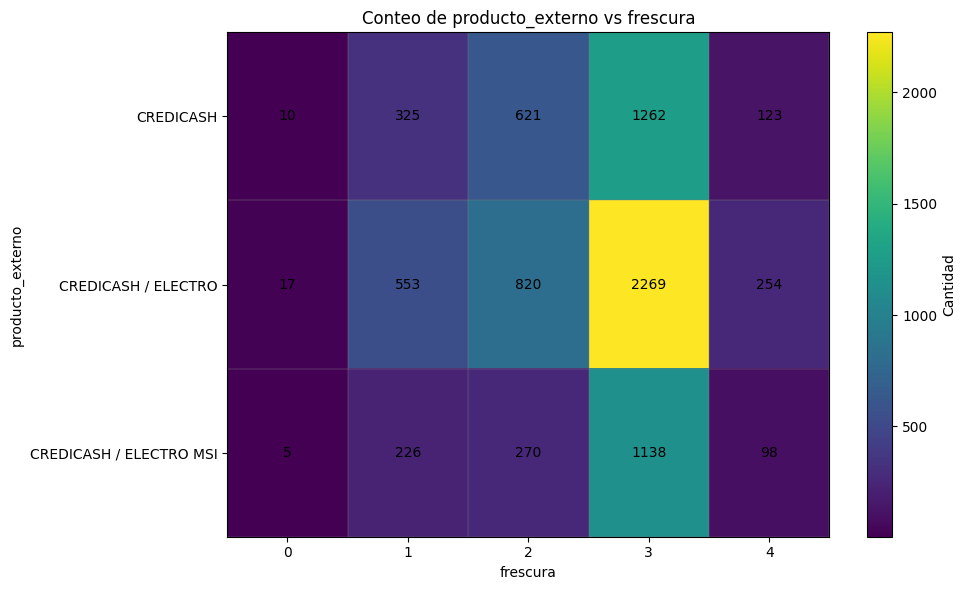

In [18]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df_plot = (
    df_filtrado.groupBy("producto_externo", "frescura")
    .count()
)

pdf = df_plot.toPandas()

pdf["frescura"] = pdf["frescura"].fillna("NULL").astype(str)
pdf["producto_externo"] = pdf["producto_externo"].fillna("NULL").astype(str)

tabla = pdf.pivot(index="producto_externo", columns="frescura", values="count").fillna(0)
tabla = tabla.sort_index()
tabla = tabla.reindex(sorted(tabla.columns, key=lambda x: str(x)), axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(tabla.values, aspect="auto")

ax.set_xticks(np.arange(-.5, len(tabla.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(tabla.index), 1), minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.3)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_title("Conteo de producto_externo vs frescura")
ax.set_xlabel("frescura")
ax.set_ylabel("producto_externo")

ax.set_xticks(np.arange(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)
ax.set_yticks(np.arange(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# mostrar etiquetas dentro de cada celda
for i in range(tabla.shape[0]):
    for j in range(tabla.shape[1]):
        ax.text(j, i, int(tabla.iloc[i, j]), ha="center", va="center")

plt.colorbar(im, ax=ax, label="Cantidad")
plt.tight_layout()
plt.show()

In [56]:
spark.stop()

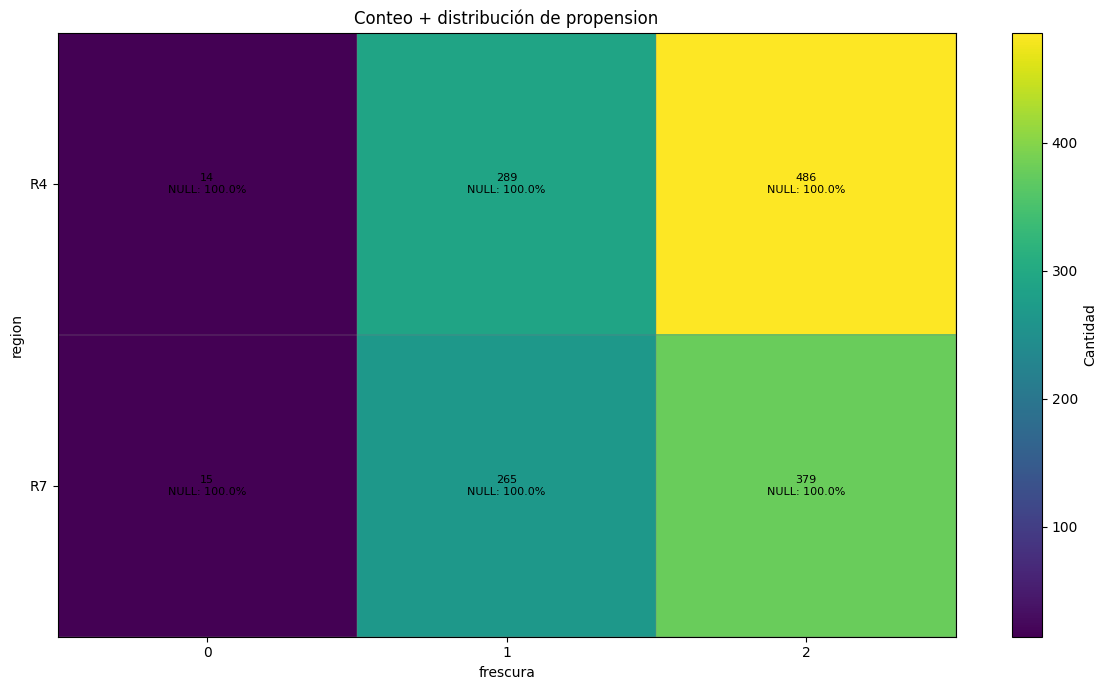

In [15]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# 1) AGRUPAR POR 3 VARIABLES
# =====================================================
df_plot = (
    df_filtrado
    .groupBy(
        "region",
        "frescura",
        "propension"
    )
    .count()
)

pdf = df_plot.toPandas()

pdf["region"] = pdf["region"].fillna("NULL").astype(str)
pdf["frescura"] = pdf["frescura"].fillna("NULL").astype(str)
pdf["propension"] = pdf["propension"].fillna("NULL").astype(str)

# =====================================================
# 2) TOTAL POR PRODUCTO + PROPENSION
# =====================================================
pdf["total_celda"] = pdf.groupby(
    ["region", "frescura"]
)["count"].transform("sum")

pdf["pct"] = pdf["count"] / pdf["total_celda"] * 100

# =====================================================
# 3) TABLA DE VOLUMEN TOTAL
# =====================================================
tabla = pdf.pivot_table(
    index="region",
    columns="frescura",
    values="total_celda",
    aggfunc="max"
).fillna(0)

tabla = tabla.sort_index()
tabla = tabla.reindex(sorted(tabla.columns, key=lambda x: str(x)), axis=1)

# =====================================================
# 4) GRAFICAR
# =====================================================
fig, ax = plt.subplots(figsize=(12, 7))

im = ax.imshow(tabla.values, aspect="auto")

ax.set_title("Conteo + distribución de propension")
ax.set_xlabel("frescura")
ax.set_ylabel("region")

ax.set_xticks(np.arange(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)

ax.set_yticks(np.arange(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# grilla
ax.set_xticks(np.arange(-.5, len(tabla.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(tabla.index), 1), minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.3)
ax.tick_params(which="minor", bottom=False, left=False)

# =====================================================
# 5) TEXTO DENTRO DE CADA CELDA
# =====================================================
for i, producto in enumerate(tabla.index):
    for j, propension in enumerate(tabla.columns):

        total = int(tabla.loc[producto, propension])

        subset = pdf[
            (pdf["region"] == producto) &
            (pdf["frescura"] == propension)
        ]

        texto_estados = "\n".join(
            subset.apply(
                lambda x: f"{x['propension']}: {x['pct']:.1f}%",
                axis=1
            )
        )

        texto = f"{total}\n{texto_estados}"

        ax.text(
            j, i,
            texto,
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(im, ax=ax, label="Cantidad")
plt.tight_layout()
plt.show()

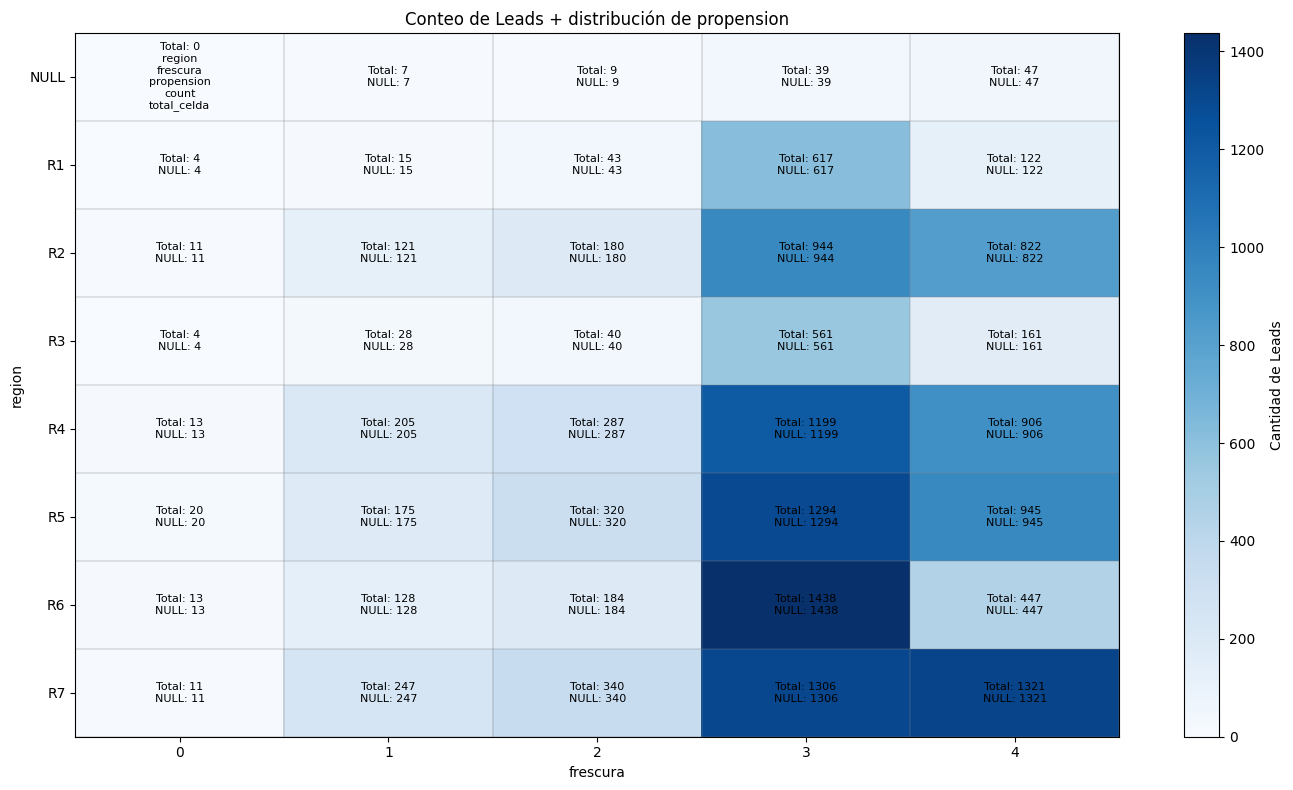

In [11]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# 1) AGRUPAR POR 3 VARIABLES
# =====================================================
df_plot = (
    df_filtrado
    .groupBy(
        "region",
        "frescura",
        "propension"
    )
    .count()
)

pdf = df_plot.toPandas()

# Manejo de nulos
pdf["region"] = pdf["region"].fillna("NULL").astype(str)
pdf["frescura"] = pdf["frescura"].fillna("NULL").astype(str)
pdf["propension"] = pdf["propension"].fillna("NULL").astype(str)

# =====================================================
# 2) TOTAL POR REGION + FRESCURA
# =====================================================
pdf["total_celda"] = pdf.groupby(
    ["region", "frescura"]
)["count"].transform("sum")

# =====================================================
# 3) TABLA PARA HEATMAP
# =====================================================
tabla = pdf.pivot_table(
    index="region",
    columns="frescura",
    values="total_celda",
    aggfunc="max"
).fillna(0)

tabla = tabla.sort_index()
tabla = tabla.reindex(
    sorted(tabla.columns, key=lambda x: str(x)),
    axis=1
)

# =====================================================
# 4) GRAFICAR
# =====================================================
fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(
    tabla.values,
    aspect="auto",
    cmap="Blues"
)

ax.set_title("Conteo de Leads + distribución de propension")
ax.set_xlabel("frescura")
ax.set_ylabel("region")

ax.set_xticks(np.arange(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)

ax.set_yticks(np.arange(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# =====================================================
# 5) GRID
# =====================================================
ax.set_xticks(
    np.arange(-.5, len(tabla.columns), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-.5, len(tabla.index), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="gray",
    linestyle="-",
    linewidth=0.3
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

# =====================================================
# 6) TEXTO DENTRO DE CADA CELDA
# =====================================================
for i, region in enumerate(tabla.index):

    for j, frescura in enumerate(tabla.columns):

        total = int(tabla.loc[region, frescura])

        subset = pdf[
            (pdf["region"] == region) &
            (pdf["frescura"] == frescura)
        ]

        # Texto por propension mostrando cantidad de leads
        texto_propension = "\n".join(
            subset.sort_values("propension").apply(
                lambda x: f"{x['propension']}: {int(x['count'])}",
                axis=1
            )
        )

        texto = f"Total: {total}\n{texto_propension}"

        ax.text(
            j,
            i,
            texto,
            ha="center",
            va="center",
            fontsize=8,
            color="black"
        )

# =====================================================
# 7) COLORBAR
# =====================================================
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Cantidad de Leads")

plt.tight_layout()
plt.show()

In [ ]:
df_list.groupBy('frescura') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+--------+-----+
|frescura|count|
+--------+-----+
|4       |8251 |
|3       |2839 |
|2       |1607 |
|1       |1231 |
+--------+-----+



In [21]:
df_filtrado.groupBy('mejor15_descripcion_cli') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+-------------------------------------------------+-----+
|mejor15_descripcion_cli                          |count|
+-------------------------------------------------+-----+
|DISCADOR                                         |16601|
|NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO       |2110 |
|CORTA LLAMADA                                    |1927 |
|BRINDARÁ INFORMACIÓN A TITULAR                   |447  |
|DERIVA A CASILLA DE VOZ                          |299  |
|NO BRINDARÁ INFORMACIÓN A TITULAR                |267  |
|NO CONTESTAN                                     |248  |
|NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES|156  |
|YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD            |107  |
|NULL                                             |97   |
|TELÉFONO APAGADO                                 |92   |
|ALFIN NO TIENE SUCURSAL CERCA                    |16   |
|NO CONOCE ALFIN BANCO                            |1    |
+-------------------------------------------------+-----+



In [20]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

w = Window.partitionBy('perfil','producto_externo',"frescura",'propension_credicash').orderBy(F.rand())

df_split = df_filtrado.withColumn("grupo_split", F.ntile(3).over(w))

df_parte_1 = df_split.filter(F.col("grupo_split") == 1).drop("grupo_split")
df_parte_2 = df_split.filter(F.col("grupo_split") == 2).drop("grupo_split")
df_parte_3 = df_split.filter(F.col("grupo_split") == 3).drop("grupo_split")
# df_parte_4 = df_split.filter(F.col("grupo_split") == 4).drop("grupo_split")
# df_parte_5 = df_split.filter(F.col("grupo_split") == 5).drop("grupo_split")
# df_parte_6 = df_split.filter(F.col("grupo_split") == 6).drop("grupo_split")
# df_parte_7 = df_split.filter(F.col("grupo_split") == 7).drop("grupo_split")

print(
    df_parte_1.count(),
    df_parte_2.count(),
    df_parte_3.count()
    # df_parte_4.count()
    # df_parte_5.count(),
    # df_parte_6.count(),
    # df_parte_7.count()
)

4794 4721 4667


In [ ]:
['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutvo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro']prope
v

In [19]:
from pyspark.sql.window import Window

window_agencia = Window.partitionBy('region',"tienda_ir")

df_final = df_filtrado.withColumn(
    "cnt_agencia",
    F.count("*").over(window_agencia)
)
df_final=df_final.filter(
    F.col("cnt_agencia") > 100
)
print(df_final.count())


4122


In [ ]:
import os

def exportar_excel(df, columnas, ruta_base, nombre_archivo):
    """
    df: DataFrame de PySpark
    columnas: lista de columnas a seleccionar
    ruta_base: carpeta donde guardar
    nombre_archivo: nombre del archivo (sin extensión opcional)
    """
    
    df_filtrado = df.select(*columnas).toPandas()
    
    ruta = os.path.join(ruta_base, f"{nombre_archivo}.xlsx")
    
    df_filtrado.to_excel(ruta, index=False)
    
    print(f"Archivo guardado en: {ruta}")

In [ ]:
['dni_cliente', 'cabecera_carga', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro', 'lote_01', 'id', 'NUMERO_DOCUMENTO']

['dni_cliente', 'cabecera_carga', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash'

In [35]:
df_list_filtrada = df_filtrado.select(
    'cabecera_carga','tienda_ir','region','semaforo'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'id55_crewdi.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [ ]:
['dni_cliente', 'cabecera_carga', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro', 'lote_01']

['dni_cliente', 'cabecera_carga', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'oferta_max', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'seg_oferta', 'seg_oferta_credicash', 'seg_oferta_electro', 'seg_tasa_credicash', 'seg_tasa_electro', 'seg_cme_electro', 'seg_cme_credicash'

In [15]:
producto_externo=[
 'CREDICASH',
 'CREDICASH R / ELECTRO',
 ]
# producto_externo=['CREDICASH R / ELECTRO MSI', 'CREDICASH R / ELECTRO', 'CREDICASH R', 'CREDICASH / ELECTRO', 'CREDICASH', 'CREDICASH / ELECTRO MSI']


['CREDICASH']

In [20]:
df_list_filtrada = df_filtrado.select(
    'cabecera_carga',
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'cregfhxxx__1.csv')

import csv

df_list_filtrada.to_csv(
    ruta_archivo,
    index=False,
    sep=",",
    header=False,
    encoding="latin-1", 
    lineterminator="\r\n"
)


df_list_filtrada.count()

cabecera_carga    7873
dtype: int64

In [ ]:
producto_externo=[
    'CREDICASH R / ELECTRO MSI',
 'CREDICASH R / ELECTRO',
 'CREDICASH',
 ]



In [15]:
df_filtrado.groupBy('producto_externo') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+-----------------------+-----+
|producto_externo       |count|
+-----------------------+-----+
|CREDICASH / ELECTRO    |5077 |
|CREDICASH / ELECTRO MSI|3908 |
|CREDICASH              |889  |
+-----------------------+-----+



In [40]:
df_filtrado.groupBy('producto_externo') \
    .count() \
    .orderBy('producto_externo') \
    .show(30, truncate=False)

+-------------------------+-----+
|producto_externo         |count|
+-------------------------+-----+
|CREDICASH / ELECTRO      |5416 |
|CREDICASH / ELECTRO MSI  |2079 |
|CREDICASH R / ELECTRO    |156  |
|CREDICASH R / ELECTRO MSI|27   |
+-------------------------+-----+



In [ ]:
producto_externo=[
    'CREDICASH R / ELECTRO MSI',
 'CREDICASH R / ELECTRO',
 'CREDICASH R',
 'CREDICASH / ELECTRO',
 'CREDICASH',
 ]


In [ ]:

df_dni = df_filtrado.toPandas()

import os

ruta_archivo = os.path.join(ruta_csv, 'credicash_.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [11]:
print([row['perfil' ] for row in df_list.select('perfil').distinct().collect()])


['O1', 'D1', 'O2', 'O3', 'D2', 'D0']


['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'AUTODIAL NO RESPONDE (AUTO)', 'OCUPADO (AUTO)', 'GESTION EN PROCESO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'AGENTE NO DISPONIBLE (AUTO)']


In [ ]:

exportar_lista(df_filtrado,'tc_cenco_2026033014.xlsx','linea_cencosud')

In [50]:
cantidad_leads=df_filtrado.count()

In [56]:
info_list=f"""
Se tienen {cantidad_leads} leads
Prioridad : {quintil}
maximo de intentos por num telef: {q_intentos_telef}
flg_ex_cliente :{flg_ex_cliente}
{segmento}
{first_name}

"""

print(info_list)


Se tienen 2814 leads
Prioridad : ['1', '2']
maximo de intentos por num telef: 40
flg_ex_cliente :['NUEVO']
['TC2', 'TC1']
['SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']




In [79]:
exportar_lista(df_filtrado,'tc_cencor_202603310847.xlsx','linea_cencosud')

['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'NUMERO DESCONECTADO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


In [ ]:
import os

ruta_archivo = os.path.join(ruta_csv, 'ivr_202603271706.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [142]:

df_dni = df_filtrado.toPandas()


In [73]:
los pu pm los qu epodemos usar


SyntaxError: invalid syntax (2290498890.py, line 1)

In [12]:

nombre_archivo_xlsx='SAE_202603251722.xlsx'
columna_ref='linea_sae'
exportar_lista(df_filtrado,nombre_archivo_xlsx,columna_ref)


In [ ]:
fecha_mes_base='2026-03-01'
t_maestra='Base_Maestra_Cencosud_PPFF'
t_name_vigente='Base_Maestra_Cencosud_PPFF_vigente'
t_mumeros='tNumeroCenco_Sae'
cols_drop=[ 'FRESCURA_TARGET', 'REP1', 'REP2', 'REP3','FLAT2']


In [97]:
df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
)
df_dni = df_filtrado.toPandas()

In [ ]:
import matplotlib.pyplot as plt

df_dni['email'].value_counts().plot(kind='bar')

plt.title('Top departamentos (email)')
plt.xlabel('Departamento')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

In [8]:
df_list.select('retiro_01').filter(col('retiro_01')==0).count()

2266

In [13]:
# print([row['first_name'] for row in df_list.select('first_name').distinct().collect()])
# print([row['title'] for row in df_list.select('title').distinct().collect()])
# print([row['tip_prioridad'] for row in df_list.select('tip_prioridad').distinct().collect()])
# print([row['email'] for row in df_list.select('email').distinct().collect()])
# print([row['prioridada'] for row in df_list.select('prioridada').distinct().collect()])
print([row['mejor15_descripcion_telf' ] for row in df_list.select('mejor15_descripcion_telf').distinct().collect()])
# print(df_list.columns)


['PERSONA FALLECIDA', 'VOLVER A LLAMAR', 'LO VA A PENSAR', 'DESEA ELECTRO', 'NEGOCIO EN ZONA NO COBERTURADA', 'TITULAR CONTAGIADO CON COVID - 19', 'CREDITO CONCRETADO', 'MENSAJES CON TERCEROS - HIJOS', 'NO DESEA SER CONTACTADO / MANIFIESTA SU RECHAZO', 'NO NECESITA / NO DESEA', 'TELEFONO APAGADO', 'NUMERO EQUIVOCADO', 'ESTA ENDEUDADO', 'MENSAJES CON TERCEROS - ESPOSA', 'OTROS', 'NO CONTESTA ', 'TITULAR NO CALIFICA- GIRO RESTRINGIDO9', 'CLIENTE RECHAZADO', 'MENSAJES CON TERCEROS - OTROS', 'NO BRINDA CONSENTIMIENTO', 'CASA EN ZONA NO COBERTURADA', 'SI QUIERE', 'CLIENTE DE VIAJE', 'TELEFONO FUERA DE SERVICIO/SUSPENDIDO', 'CONFIRMAR CITA', 'INTERESES ELEVADOS', 'NUMERO NO EXISTE', 'TITULAR NO CALIFICA - DESEMPLEO', 'MENSAJES DE TEXTO', 'TONO OCUPADO', 'SOLICITA SER RETIRADO', 'IVR - NO CONFIRMA', 'MALA EXPERIENCIA (TDA/FNC)', 'DESEA MAS MONTO', 'NO QUIERE', None]
